# Universal Dependencies - English Dependency Treebank Universal Dependencies 

### Exploratory scaffold using English UD
This exploratory analysis uses the [UD English Web Treebank (UD_EWT)](https://universaldependencies.org/treebanks/en_ewt/index.html) as a reference scaffold to understand the structure and annotation schema used in [Universal Dependencies](https://universaldependencies.org/)—particularly for Part-of-Speech tagging and syntactic dependencies. While English and Hawaiian are linguistically distinct, this corpus provides a rich and well-documented example of how dependency trees are structured, annotated, and processed at scale.




The corpus comprises 254,820 words and 16,622 sentences, taken from five genres of web media: weblogs, newsgroups, emails, reviews, and Yahoo! answers. See the LDC2012T13 documentation for more details on the sources of the sentences. The trees were automatically converted into Stanford Dependencies and then hand-corrected to Universal Dependencies. All the basic dependency annotations have been single-annotated, a limited portion of them have been double-annotated, and subsequent correction has been done to improve consistency. Other aspects of the treebank, such as Universal POS, features and enhanced dependencies, has mainly been done automatically, with very limited hand-correction.

In [11]:
from datasets import load_dataset
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from collections import Counter
from IPython.display import display
from itertools import chain

# Load the Universal Dependencies dataset for English (EWT)
# This dataset contains various linguistic annotations for English sentences.
# It is useful for tasks such as part-of-speech tagging.
ds = load_dataset("universal_dependencies", "en_ewt")

# Split Structure

The UD English Web Treebank (UD_EWT) is split into train, validation, and test sets, as visualized in the pie chart above. The majority of the dataset (75.5%) is allocated to training, ensuring sufficient data for learning dependency structures and POS tag distributions. Validation and test sets are almost evenly split, with 12.0% and 12.5% respectively, supporting model tuning and evaluation without significant data leakage or imbalance.

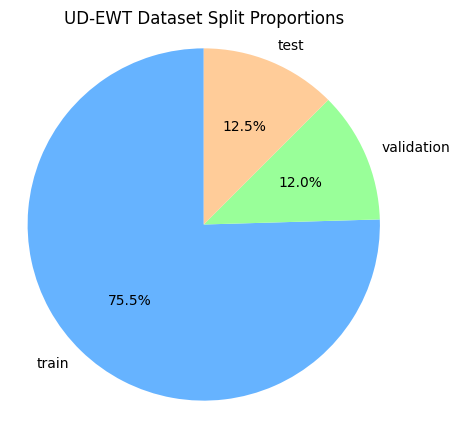

,split,sentences,tokens,avg sent-len,max sent-len
0,train,12543,207053,16.5,160
1,validation,2002,25478,12.7,77
2,test,2077,25429,12.2,84


In [19]:
# Here we examine the train, test, and validation splits of the dataset.
split_names = list(ds.keys())
split_counts = [len(ds[split]) for split in split_names]

# Pie chart to visualize the distribution of dataset splits
plt.figure(figsize=(5,5))
plt.pie(split_counts, labels=split_names, autopct='%1.1f%%', startangle=90, colors=["#66b3ff", "#99ff99", "#ffcc99"])
plt.title("UD-EWT Dataset Split Proportions")
plt.axis('equal')
plt.show()

# High-level overview of the dataset - number of sentences, tokens, and average sentence length
rows = []
for split, dset in ds.items():
    lens = [len(t) for t in dset["tokens"]]
    rows.append({
        "split"          : split,
        "sentences"      : len(dset),
        "tokens"         : int(np.sum(lens)),
        "avg sent-len"   : round(np.mean(lens), 1),
        "max sent-len"   : int(np.max(lens)),
    })
summary = pd.DataFrame(rows)
display(summary)

### Universal POS Tags Overview

The Universal Dependencies (UD) framework provides a standardized set of **Universal Part-of-Speech (UPOS)** tags. These tags allow for **cross-linguistic comparisons** and consistent annotation of morphosyntactic features across languages.

Below is a table of UPOS tags found in the UD English Web Treebank, along with their descriptions and an example (optional: counts can be included with `Counter` from Python):

| Tag     | Full Name                 | Description                                                   |
| ------- | ------------------------- | ------------------------------------------------------------- |
| `ADJ`   | Adjective                 | Describes a noun (e.g., *beautiful*, *fast*)                  |
| `ADP`   | Adposition                | Prepositions or postpositions (e.g., *in*, *on*)              |
| `ADV`   | Adverb                    | Modifies verbs or adjectives (e.g., *quickly*)                |
| `AUX`   | Auxiliary                 | Helping verbs (e.g., *is*, *have*)                            |
| `CCONJ` | Coordinating Conjunction  | Joins clauses or phrases (e.g., *and*, *but*)                 |
| `DET`   | Determiner                | Specifies nouns (e.g., *the*, *a*)                            |
| `INTJ`  | Interjection              | Expresses emotion (e.g., *wow*, *ouch*)                       |
| `NOUN`  | Noun                      | Person, place, or thing (e.g., *cat*, *city*)                 |
| `NUM`   | Numeral                   | Expresses quantity (e.g., *two*, *100*)                       |
| `PART`  | Particle                  | Function word with no clear category (e.g., *to* in *to run*) |
| `PRON`  | Pronoun                   | Replaces a noun (e.g., *he*, *they*)                          |
| `PROPN` | Proper Noun               | Specific names (e.g., *Hawaii*, *Alice*)                      |
| `PUNCT` | Punctuation               | Marks boundaries or pauses (e.g., *,*, *.*)                   |
| `SCONJ` | Subordinating Conjunction | Introduces subordinate clauses (e.g., *because*)              |
| `SYM`   | Symbol                    | Mathematical, currency, etc. (e.g., *\$*, *%*)                |
| `VERB`  | Verb                      | Action or state (e.g., *run*, *be*)                           |
| `X`     | Other                     | Unknown or foreign words                                      |
| `_`     | Missing                   | Placeholder when no tag assigned                              |

# Part of Speech Distribution

The following table shows the distribution of parts of speech (POS) in the dataset. The table includes the count and percentage of each POS tag. The most common tags are the NOUN, followed by PUNCT, VERB, etc.



In [29]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# Get the tag index-to-name mapping
id2tag = ds[split].features["upos"].feature.names

# Flatten the list of UPOS tag ids (each sentence has its own list)
all_tag_ids = [tag_id for sentence in ds[split]["upos"] for tag_id in sentence]

# Count frequency of each tag id
upos_counts = Counter(all_tag_ids)

# Convert to a DataFrame with readable tag names
df_upos = (
    pd.DataFrame(
        [(id2tag[i], c) for i, c in upos_counts.items()],
        columns=["upos_tag", "count"]
    )
    .sort_values("count", ascending=False)
    .assign(percent=lambda d: (d["count"] / d["count"].sum() * 100).round(2))
    .reset_index(drop=True)
)

# Show the table
df_upos


,upos_tag,count,percent
0,NOUN,4129,16.24
1,PUNCT,3106,12.21
2,VERB,2644,10.40
3,PRON,2158,8.49
4,PROPN,2075,8.16
5,ADP,2020,7.94
6,DET,1896,7.46
7,ADJ,1689,6.64
8,AUX,1505,5.92
9,ADV,1169,4.60


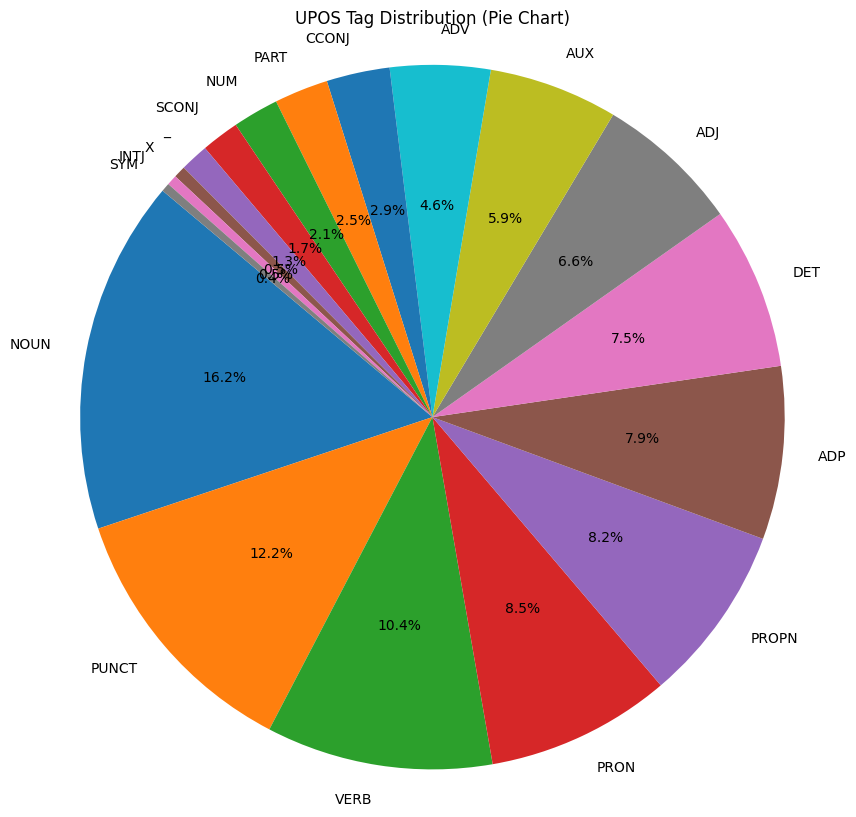

In [33]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# Get the tag index-to-name mapping
id2tag = ds[split].features["upos"].feature.names

# Flatten the list of UPOS tag ids (each sentence has its own list)
all_tag_ids = [tag_id for sentence in ds[split]["upos"] for tag_id in sentence]

# Count frequency of each tag id
upos_counts = Counter(all_tag_ids)

# Convert to a DataFrame with readable tag names
df_upos = (
    pd.DataFrame(
        [(id2tag[i], c) for i, c in upos_counts.items()],
        columns=["upos_tag", "count"]
    )
    .sort_values("count", ascending=False)
    .assign(percent=lambda d: (d["count"] / d["count"].sum() * 100).round(2))
    .reset_index(drop=True)
)

# Show the table
df_upos
df_upos["percent"] = (df_upos["count"] / df_upos["count"].sum() * 100).round(2)

# Plot pie chart
plt.figure(figsize=(10, 10))
plt.pie(
    df_upos["count"],
    labels=df_upos["upos_tag"],
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 10}
)
plt.title("UPOS Tag Distribution (Pie Chart)")
plt.axis('equal')
plt.show()


### Structure of *tokens*, *encoded UPOS*, and *human-readable UPOS*

The snippet below previews the first five sentences in every split (`train`, `validation`, `test`) to help you sanity-check the raw data layout:

| Column       | Type / Shape | Meaning                                                                                                 |
|--------------|--------------|---------------------------------------------------------------------------------------------------------|
| **tokens**   | `List[str]`  | The surface form of each sentence, already tokenized by UD_EWT (punctuation is included as separate tokens). |
| **upos**     | `List[int]`  | A parallel list of integer IDs—each ID indexes into the Universal POS tag set provided by the dataset schema. |
| **upos_str** | `List[str]`  | A convenience column created on-the-fly: the integer IDs are mapped back to their string labels (e.g., `NOUN`, `VERB`). This lets us inspect tag quality at a glance. |

Because each row represents **one full sentence**, `tokens[i]`, `upos[i]`, and `upos_str[i]` are guaranteed to be the same length.  

With this structure, we can easily create a machine learning dataset by pairing the `tokens` with their corresponding `upos`.  For example, we could train a model 
to predict the part-of-speech tag of each token in a sentence. 


In [30]:
# Show first 5 rows of the actual data for each split, with UPOS as string
for split in ds.keys():
    print(f"\nFirst 5 rows from the '{split}' split:")
    df = pd.DataFrame({
        "tokens": ds[split]["tokens"],
        "upos": ds[split]["upos"]
    })
    # Map UPOS indices to string labels
    upos_names = ds[split].features["upos"].feature.names
    df["upos_str"] = df["upos"].apply(lambda tags: [upos_names[i] for i in tags])
    display(df.head())


First 5 rows from the 'train' split:


,tokens,upos,upos_str
0,"[Al, -, Zaman, :, American, forces, killed, Sh...","[10, 1, 10, 1, 6, 0, 16, 10, 10, 10, 1, 10, 1,...","[PROPN, PUNCT, PROPN, PUNCT, ADJ, NOUN, VERB, ..."
1,"[[, This, killing, of, a, respected, cleric, w...","[1, 8, 0, 2, 8, 6, 0, 17, 17, 16, 11, 0, 2, 0,...","[PUNCT, DET, NOUN, ADP, DET, ADJ, NOUN, AUX, A..."
2,"[DPA, :, Iraqi, authorities, announced, that, ...","[10, 1, 6, 0, 16, 5, 11, 17, 16, 2, 3, 6, 0, 1...","[PROPN, PUNCT, ADJ, NOUN, VERB, SCONJ, PRON, A..."
3,"[Two, of, them, were, being, run, by, 2, offic...","[3, 2, 11, 17, 17, 16, 2, 3, 0, 2, 8, 10, 2, 8...","[NUM, ADP, PRON, AUX, AUX, VERB, ADP, NUM, NOU..."
4,"[The, MoI, in, Iraq, is, equivalent, to, the, ...","[8, 10, 2, 10, 17, 6, 2, 8, 10, 10, 1, 14, 11,...","[DET, PROPN, ADP, PROPN, AUX, ADJ, ADP, DET, P..."



First 5 rows from the 'validation' split:


,tokens,upos,upos_str
0,"[From, the, AP, comes, this, story, :]","[2, 8, 10, 16, 8, 0, 1]","[ADP, DET, PROPN, VERB, DET, NOUN, PUNCT]"
1,"[President, Bush, on, Tuesday, nominated, two,...","[10, 10, 2, 10, 16, 3, 0, 7, 16, 16, 0, 2, 6, ...","[PROPN, PROPN, ADP, PROPN, VERB, NUM, NOUN, PA..."
2,"[Bush, nominated, Jennifer, M., Anderson, for,...","[10, 16, 10, 10, 10, 2, 8, 3, 1, 0, 0, 2, 6, 0...","[PROPN, VERB, PROPN, PROPN, PROPN, ADP, DET, N..."
3,[***],[1],[PUNCT]
4,"[Bush, also, nominated, A., Noel, Anketell, Kr...","[10, 14, 16, 10, 10, 10, 10, 2, 8, 3, 1, 0, 0,...","[PROPN, ADV, VERB, PROPN, PROPN, PROPN, PROPN,..."



First 5 rows from the 'test' split:


,tokens,upos,upos_str
0,"[What, if, Google, Morphed, Into, GoogleOS, ?]","[11, 5, 10, 16, 2, 10, 1]","[PRON, SCONJ, PROPN, VERB, ADP, PROPN, PUNCT]"
1,"[What, if, Google, expanded, on, its, search, ...","[11, 5, 10, 16, 2, 11, 0, 1, 0, 1, 9, 14, 0, 1...","[PRON, SCONJ, PROPN, VERB, ADP, PRON, NOUN, PU..."
2,"[[, via, Microsoft, Watch, from, Mary, Jo, Fol...","[1, 2, 10, 10, 2, 10, 10, 10, 1]","[PUNCT, ADP, PROPN, PROPN, ADP, PROPN, PROPN, ..."
3,"[(, And, ,, by, the, way, ,, is, anybody, else...","[1, 9, 1, 2, 8, 0, 1, 17, 11, 6, 14, 8, 6, 0, ...","[PUNCT, CCONJ, PUNCT, ADP, DET, NOUN, PUNCT, A..."
4,"[This, BuzzMachine, post, argues, that, Google...","[8, 10, 0, 16, 5, 13, 10, 7, 0, 2, 0, 17, 16, ...","[DET, PROPN, NOUN, VERB, SCONJ, _, PROPN, PART..."
